In [ ]:
!pip uninstall torchaudio torchtune torchvision
!pip install torch==2.0.1+cu118 torchtext==0.15.2 -f https://download.pytorch.org/whl/torch_stable.html

Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/torchaudio-2.6.0+cu124.dist-info/*
    /usr/local/lib/python3.11/dist-packages/torchaudio/*
    /usr/local/lib/python3.11/dist-packages/torio/*
Proceed (Y/n)? y
  Successfully uninstalled torchaudio-2.6.0+cu124
Found existing installation: torchtune 0.6.1
Uninstalling torchtune-0.6.1:
  Would remove:
    /usr/local/bin/tune
    /usr/local/lib/python3.11/dist-packages/recipes/*
    /usr/local/lib/python3.11/dist-packages/torchtune-0.6.1.dist-info/*
    /usr/local/lib/python3.11/dist-packages/torchtune/*
Proceed (Y/n)? y
  Successfully uninstalled torchtune-0.6.1
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/torchvision-0.21.0+cu124.dist-info/*
    /usr/local/lib/python3.11/dist-packages/torchvision.libs/libcudart.41118559.so.12
    /us

In [ ]:
import torch
import torchtext
import numpy as np
import pandas as pd

print(f"PyTorch Version: {torch.__version__}")
print(f"TorchText Version: {torchtext.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")

print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA 버전: {torch.version.cuda}")
    print(f"현재 GPU 이름: {torch.cuda.get_device_name(0)}")

--- 필수 라이브러리 임포트 및 버전 확인 ---
PyTorch Version: 2.0.1+cu118
TorchText Version: 0.15.2+cpu
NumPy Version: 2.0.2
Pandas Version: 2.2.2
CUDA 사용 가능 여부: True
CUDA 버전: 11.8
현재 GPU 이름: Tesla T4

--- 초기 환경 설정 및 라이브러리 준비 완료 ---


In [ ]:
# --- 1. 라이브러리 임포트 ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchtext.vocab import build_vocab_from_iterator
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from torchtext.vocab import vocab, build_vocab_from_iterator
import re
from tqdm.auto import tqdm
import math
from torch.optim.lr_scheduler import ReduceLROnPlateau

# NLTK 관련 임포트 (데이터 로드 후 사용)
print("\n--- NLTK 데이터 다운로드 시작 ---")
import nltk
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("stopwords")
nltk.download("punkt_tab")
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

print("--- 모든 라이브러리 임포트 완료 ---")

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    import random
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

train_df = pd.read_csv('train.tsv', sep='\t', header=0)
test_df = pd.read_csv('test.tsv', sep='\t', header=0)
train_df.head()


--- NLTK 데이터 다운로드 시작 ---


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


--- 모든 라이브러리 임포트 완료 ---


,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
1,2,1,A series of escapades demonstrating the adage ...,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2


# **전처리**
- stopwords 제거X(not, very 등 강조 단어 제거 우려)
- frequency 봤을때 의미없는 rrb, lrb 등 제거

In [ ]:
# 초기 설정
lemmatizer = WordNetLemmatizer()
#stop_words = set(stopwords.words("english")) stop_words 사용X

# 제거 대상 불용 단어 (의미 없음)
remove_tokens = {'rrb', 'lrb', 'n', 'u'}

# 전처리 함수
def clean_text(text):
    if not isinstance(text, str):
        text = str(text)

    text = re.sub(r"[^a-zA-Z0-9]", " ", text)  # 특수문자 제거
    tokens = word_tokenize(text.lower())       # 소문자 & 토큰화
    tokens = [token for token in tokens if token.strip()]
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in remove_tokens]
    return tokens

# 전처리 적용
train_tokens = train_df['Phrase'].apply(clean_text).tolist()
test_tokens = test_df['Phrase'].apply(clean_text).tolist()

# vocab 생성
all_tokens = train_tokens + test_tokens


counter = Counter()
for tokens in all_tokens:
    counter.update(tokens)

vocab = build_vocab_from_iterator(all_tokens, min_freq=1, specials=['<pad>', '<unk>'])
vocab.set_default_index(vocab['<unk>'])

# 인덱스 변환
def tokens_to_ids(tokens):
    return torch.tensor([vocab[token] for token in tokens], dtype=torch.long)

train_ids = [tokens_to_ids(toks) for toks in train_tokens]
test_ids = [tokens_to_ids(toks) for toks in test_tokens]

# 시퀀스 길이 기준 계산 (mean + 2*std)
all_lens = [len(seq) for seq in train_ids + test_ids]
max_len = int(np.mean(all_lens) + 2*np.std(all_lens))

# 패딩
train_padded = pad_sequence(train_ids, batch_first=True, padding_value=vocab['<pad>'])
test_padded = pad_sequence(test_ids, batch_first=True, padding_value=vocab['<pad>'])

# 길이 조정
def adjust_pad(x, max_len):
    if x.shape[1] > max_len:
        return x[:, :max_len]
    else:
        pad_width = max_len - x.shape[1]
        return torch.nn.functional.pad(x, (0, pad_width), value=vocab['<pad>'])

train_padded = adjust_pad(train_padded, max_len)
test_padded = adjust_pad(test_padded, max_len)

# 출력 확인
print("train_padded:", train_padded.shape)
print("test_padded :", test_padded.shape)
print("vocab size  :", len(vocab))
print("First 50 words in vocab:", vocab.get_itos()[:50])

train_padded: torch.Size([156060, 19])
test_padded : torch.Size([66292, 19])
vocab size  : 16065
First 50 words in vocab: ['<pad>', '<unk>', 'the', 'a', 'of', 'and', 'to', 'it', 's', 'in', 'is', 'that', 'with', 'film', 'for', 'movie', 'an', 'this', 'but', 'be', 'on', 'you', 'by', 't', 'more', 'his', 'one', 'not', 'than', 'about', 'at', 'from', 'or', 'all', 'like', 'are', 'have', 'ha', 'character', 'so', 'story', 'out', 'time', 'make', 'who', 'up', 'good', 'too', 'most', 'into']


# **임베딩**

In [ ]:
embedding_dim = 100
embedding_path = "glove.6B.100d.txt"

# 1. GloVe 파일 읽기
glove_embeddings = {}
with open(embedding_path, 'r', encoding='utf8') as f:
    for line in f:
        values = line.strip().split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = vector

# 2. embedding_matrix 생성
embedding_matrix = np.zeros((len(vocab), embedding_dim), dtype='float32')

for idx, token in enumerate(vocab.get_itos()):
    vector = glove_embeddings.get(token)
    if vector is not None:
        embedding_matrix[idx] = vector
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))  # OOV

# 3. PyTorch Tensor로 변환
embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

# 4. 확인
print("embedding_tensor.shape:", embedding_tensor.shape)

embedding_tensor.shape: torch.Size([16065, 100])


# **LSTM -> GRU**

In [ ]:
embedding_layer = nn.Embedding.from_pretrained(embedding_tensor, freeze=False)

# 기존 SentimentRNN 클래스 재정의
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,
                 bidirectional=True, dropout_rate=0.5, embedding_weights=None, freeze_embedding=False):
        super().__init__()

        # 임베딩 레이어
        if embedding_weights is not None:
            self.embedding = nn.Embedding.from_pretrained(embedding_weights, freeze=freeze_embedding)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.dropout_embedding = nn.Dropout(dropout_rate)

        # 구조 하이퍼파라미터 정의
        self.hidden_lstm1 = hidden_dim
        self.hidden_lstm2 = hidden_dim // 2
        self.hidden_gru1 = hidden_dim // 4
        self.hidden_gru2 = hidden_dim // 8

        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # LSTM → LSTM → GRU → GRU
        self.lstm1 = nn.LSTM(embedding_dim,
                             self.hidden_lstm1,
                             num_layers=1,
                             bidirectional=bidirectional,
                             dropout=0.0,
                             batch_first=True)

        self.lstm2 = nn.LSTM(self.hidden_lstm1 * self.num_directions,
                             self.hidden_lstm2,
                             num_layers=1,
                             bidirectional=bidirectional,
                             dropout=0.0,
                             batch_first=True)

        self.gru1 = nn.GRU(self.hidden_lstm2 * self.num_directions,
                           self.hidden_gru1,
                           num_layers=1,
                           bidirectional=bidirectional,
                           batch_first=True)

        self.gru2 = nn.GRU(self.hidden_gru1 * self.num_directions,
                           self.hidden_gru2,
                           num_layers=1,
                           bidirectional=bidirectional,
                           batch_first=True)

        self.dropout_rnn_output = nn.Dropout(dropout_rate)

        # 최종 FC 레이어의 입력 차원 변경
        self.fc = nn.Linear(self.hidden_gru2 * self.num_directions, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)
        embedded = self.dropout_embedding(embedded)

        output_1, _ = self.lstm1(embedded)
        output_2, _ = self.lstm2(output_1)
        output_gru1, hidden_gru1 = self.gru1(output_2) # 첫 번째 GRU
        output_gru2, hidden_gru2 = self.gru2(output_gru1) # 두 번째 GRU

        if self.bidirectional:
            # 최종 GRU (hidden_gru2)의 마지막 두 히든 스테이트를 연결
            hidden = torch.cat((hidden_gru2[-2,:,:], hidden_gru2[-1,:,:]), dim=1)
        else:
            hidden = hidden_gru2[-1,:,:] # 최종 GRU (hidden_gru2)의 마지막 히든 스테이트 사용

        hidden = self.dropout_rnn_output(hidden)

        return self.fc(hidden)

model = SentimentRNN(
    vocab_size=len(vocab),
    embedding_dim=100,
    hidden_dim=256,
    output_dim=5,
    bidirectional=True,
    dropout_rate=0.5,
    embedding_weights=embedding_tensor,
    freeze_embedding=False
)

# **Train, val함수**

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

train_labels = torch.tensor(train_df['Sentiment'].values, dtype=torch.long)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, val_idx in sss.split(torch.zeros(len(train_labels)), train_labels.tolist()):
    X_train = train_padded[train_idx.tolist()]
    X_val = train_padded[val_idx.tolist()]
    y_train = train_labels[train_idx.tolist()]
    y_val = train_labels[val_idx.tolist()]

# Dataset 정의
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

# DataLoader 정의
BATCH_SIZE = 128
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

def calculate_accuracy(preds, labels):
    return (torch.argmax(preds, dim=1) == labels).float().mean().item()

def train(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss, total_acc = 0, 0
    for text, labels in tqdm(dataloader):
        text, labels = text.to(device), labels.to(device)
        optimizer.zero_grad()
        predictions = model(text)
        loss = criterion(predictions, labels)
        acc = calculate_accuracy(predictions, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_acc += acc
    return total_loss / len(dataloader), total_acc / len(dataloader)

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, total_acc = 0, 0
    with torch.no_grad():
        for text, labels in dataloader:
            text, labels = text.to(device), labels.to(device)
            predictions = model(text)
            loss = criterion(predictions, labels)
            acc = calculate_accuracy(predictions, labels)
            total_loss += loss.item()
            total_acc += acc
    return total_loss / len(dataloader), total_acc / len(dataloader)


In [ ]:
N_EPOCHS = 30
best_val_loss = float('inf')
patience = 7
epochs_no_improve = 0

# 손실과 정확도 기록을 위한 리스트 초기화
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("\n--- 모델 학습 시작 ---")
for epoch in range(N_EPOCHS):
    train_loss, train_acc = train(model, train_dataloader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_dataloader, criterion, device)

    scheduler.step(val_loss) #추가

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f'Epoch: {epoch+1:02}')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {val_loss:.3f} | Val. Acc: {val_acc*100:.2f}%')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        epochs_no_improve = 0
        print(f"\t>>> Val. Loss 개선! 모델 저장됨.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f"\t>>> 검증 손실이 {patience} 에폭 동안 개선되지 않아 학습을 중단합니다.")
            break

print("\n--- 모델 학습 완료 ---")
model.load_state_dict(torch.load('best_model.pt'))
print("최적의 모델 가중치 로드 완료.")


--- 모델 학습 시작 ---


  0%|          | 0/976 [00:00<?, ?it/s]

Epoch: 01
	Train Loss: 1.068 | Train Acc: 56.63%
	 Val. Loss: 0.912 | Val. Acc: 62.08%
	>>> Val. Loss 개선! 모델 저장됨.


  0%|          | 0/976 [00:00<?, ?it/s]

Epoch: 02
	Train Loss: 0.952 | Train Acc: 60.88%
	 Val. Loss: 0.870 | Val. Acc: 63.77%
	>>> Val. Loss 개선! 모델 저장됨.


...

Epoch: 17
	Train Loss: 0.655 | Train Acc: 73.11%
	 Val. Loss: 0.767 | Val. Acc: 68.70%


  0%|          | 0/976 [00:00<?, ?it/s]

Epoch: 18
	Train Loss: 0.647 | Train Acc: 73.39%
	 Val. Loss: 0.768 | Val. Acc: 68.77%


  0%|          | 0/976 [00:00<?, ?it/s]

Epoch: 19
	Train Loss: 0.638 | Train Acc: 73.87%
	 Val. Loss: 0.769 | Val. Acc: 69.08%
	>>> 검증 손실이 7 에폭 동안 개선되지 않아 학습을 중단합니다.

--- 모델 학습 완료 ---
최적의 모델 가중치 로드 완료.


In [ ]:
test_dataset = TensorDataset(test_padded)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# **시각화**

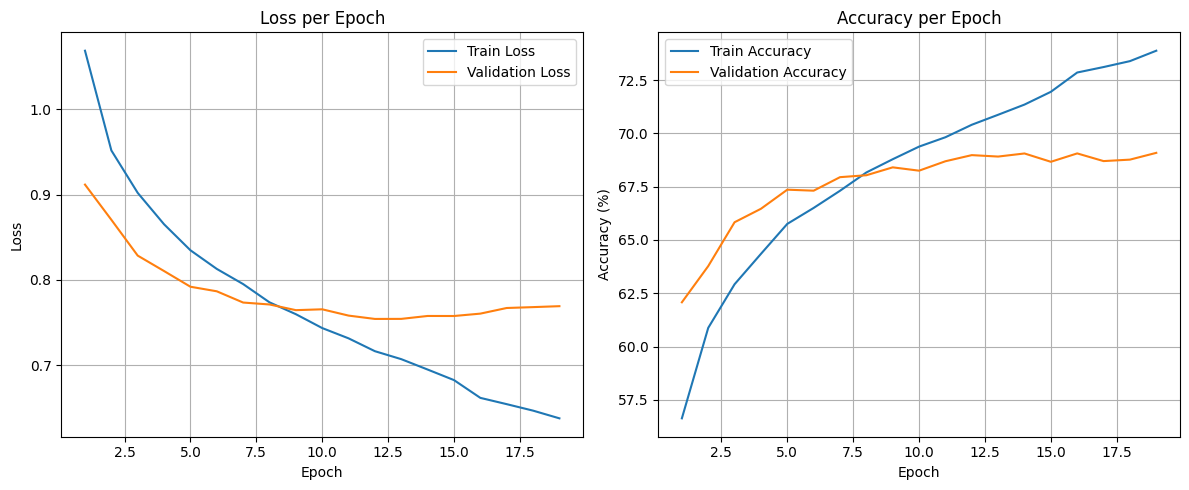

In [ ]:
# --- 학습 결과 시각화 ---
import matplotlib.pyplot as plt # 이 임포트도 여기에 두거나, 노트북 맨 위에 두세요.

epochs_ran = len(train_losses) # 실제 실행된 에포크 수

plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1) # 1행 2열 중 첫 번째 플롯
plt.plot(range(1, epochs_ran + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs_ran + 1), val_losses, label='Validation Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2) # 1행 2열 중 두 번째 플롯
plt.plot(range(1, epochs_ran + 1), [acc * 100 for acc in train_accuracies], label='Train Accuracy')
plt.plot(range(1, epochs_ran + 1), [acc * 100 for acc in val_accuracies], label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout() # 서브플롯 간의 간격 자동 조절
plt.show()

In [ ]:
def predict(model, dataloader, device):
    model.eval()
    all_preds = []

    with torch.no_grad():
        for text in dataloader:
            text = text[0].to(device)  # TensorDataset일 경우 (text,)
            output = model(text)
            preds = torch.argmax(output, dim=1)
            all_preds.extend(preds.cpu().tolist())

    return all_preds

# 예측 수행
test_preds = predict(model, test_dataloader, device)
submission_df = pd.DataFrame({
    "PhraseId": test_df["PhraseId"].values,
    "Sentiment": test_preds
})

# PhraseId는 test_df['PhraseId'] 그대로 사용
submission_df.to_csv("submission_LSTM_adamW.csv", index=False)
print("제출용 submission_LSTM.csv 저장 완료")

제출용 submission_LSTM.csv 저장 완료
